# 🌿 Betel Leaf Disease Detection — Early Fusion Model
**CSE 438 Group-4 | Fusion Method: Early Fusion (RGB + Augmented Channel Concatenation)**

---
## Pipeline Overview
| Step | Description |
|------|-------------|
| Step 1 | Install & Import Libraries |
| Step 2 | Dataset Download & Directory Setup |
| Step 3 | Data Exploration & Class Distribution |
| Step 4 | Data Augmentation & Early Fusion Transform |
| Step 5 | Dataset & DataLoader Creation |
| Step 6 | Early Fusion Model Building |
| Step 7 | Training Loop with Validation |
| Step 8 | Training Curves Visualization |
| Step 9 | Final Test Evaluation & Metrics |
| Step 10 | Confusion Matrix & Per-Class Report |

> **Fusion Type:** Early Fusion — RGB original image + augmented grayscale edge channel concatenated to form 4-channel input


---
## ✅ Step 1 — Install & Import Libraries

In [1]:
# ── Install required packages ──────────────────────────────────────────────
import subprocess, sys

packages = ["timm", "scikit-learn", "matplotlib", "seaborn", "Pillow", "torchvision"]
for pkg in packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                            capture_output=True, text=True)
    print(f"[OK] {pkg}" if result.returncode == 0 else f"[FAIL] {pkg}: {result.stderr[:80]}")

print("\n✅ All packages ready!")

# ── Core imports ───────────────────────────────────────────────────────────
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFilter
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as tv_models
import timm

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch : {torch.__version__}")
print(f"   timm    : {timm.__version__}")

[OK] timm
[OK] scikit-learn
[OK] matplotlib
[OK] seaborn
[OK] Pillow
[OK] torchvision

✅ All packages ready!

🖥️  Device : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   PyTorch : 2.10.0+cu128
   timm    : 1.0.25


---
## ✅ Step 2 — Dataset Download & Directory Setup

Dataset source: https://data.mendeley.com/datasets/vpzkntzjty/1  
**Kaggle Dataset Slug:** `vpzkntzjty` (Comprehensive Betel Leaf Disease)

> **Note:** On Kaggle, add the dataset via *Add Data → Datasets* search for `"Comprehensive Betel Leaf Disease"`, then run the cell below.

In [2]:
import os
from pathlib import Path

# ── Auto-detect dataset root ───────────────────────────────────────────────
POSSIBLE_ROOTS = [
    "/kaggle/input",
    "./data",
    "."
]

CLASS_NAMES   = ["Healthy_Leaf", "Leaf_Rot", "Leaf_Spot"]
DATASET_ROOT  = None

for root in POSSIBLE_ROOTS:
    for dirpath, dirnames, _ in os.walk(root):
        if "Original_Dataset" in dirnames:
            DATASET_ROOT = Path(dirpath) / "Original_Dataset"
            print(f"✅ Found Original_Dataset at: {DATASET_ROOT}")
            break
    if DATASET_ROOT:
        break

if DATASET_ROOT is None:
    print("⚠️  Original_Dataset not found.")
    print("   Creating synthetic demo data for pipeline demonstration...")
    # Create minimal demo structure
    DATASET_ROOT = Path("/kaggle/working/demo_dataset")
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            (DATASET_ROOT / split / cls).mkdir(parents=True, exist_ok=True)
            # Create tiny dummy images
            for i in range(30 if split=="train" else 10):
                img = Image.fromarray(np.random.randint(50, 200, (224, 224, 3), dtype=np.uint8))
                img.save(DATASET_ROOT / split / cls / f"img_{i:04d}.jpg")
    print(f"✅ Demo dataset created at: {DATASET_ROOT}")
    DEMO_MODE = True
else:
    DEMO_MODE = False

# ── If real dataset found, create train/val/test splits ───────────────────
if not DEMO_MODE:
    from sklearn.model_selection import train_test_split
    import shutil

    SPLIT_ROOT = Path("/kaggle/working/split_dataset")
    if not SPLIT_ROOT.exists():
        print("\n📁 Creating train/val/test splits (70 / 15 / 15)...")
        for cls in CLASS_NAMES:
            all_imgs = sorted((DATASET_ROOT / cls).glob("*.jpg")) + \
                       sorted((DATASET_ROOT / cls).glob("*.png")) + \
                       sorted((DATASET_ROOT / cls).glob("*.jpeg"))
            tr, temp = train_test_split(all_imgs, test_size=0.30, random_state=SEED)
            vl, te   = train_test_split(temp,     test_size=0.50, random_state=SEED)
            for split_name, imgs in [("train", tr), ("val", vl), ("test", te)]:
                dest = SPLIT_ROOT / split_name / cls
                dest.mkdir(parents=True, exist_ok=True)
                for src in imgs:
                    shutil.copy(src, dest / src.name)
            print(f"   {cls:<15} → train:{len(tr):4d}  val:{len(vl):4d}  test:{len(te):4d}")
        DATASET_ROOT = SPLIT_ROOT
        print("✅ Splits ready!")
    else:
        DATASET_ROOT = SPLIT_ROOT
        print(f"✅ Using existing splits at: {SPLIT_ROOT}")

# ── Summary ────────────────────────────────────────────────────────────────
print("\n📊 Dataset Summary:")
for split in ["train", "val", "test"]:
    total = sum(len(list((DATASET_ROOT / split / c).glob("*.*")))
                for c in CLASS_NAMES if (DATASET_ROOT / split / c).exists())
    print(f"   {split:>5}: {total:5d} images")

# ── Config ─────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE  = 32
NUM_EPOCHS  = 20
LR          = 1e-4
NUM_WORKERS = 2

print(f"\n⚙️  Config: IMG={IMG_SIZE}  Classes={NUM_CLASSES}  "
      f"Batch={BATCH_SIZE}  Epochs={NUM_EPOCHS}  LR={LR}")

✅ Found Original_Dataset at: /kaggle/input/datasets/mikeafridi/cse-438-group-4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset

📁 Creating train/val/test splits (70 / 15 / 15)...
   Healthy_Leaf    → train: 756  val: 162  test: 162
   Leaf_Rot        → train: 188  val:  40  test:  41
   Leaf_Spot       → train: 481  val: 103  test: 104
✅ Splits ready!

📊 Dataset Summary:
   train:  1425 images
     val:   305 images
    test:   307 images

⚙️  Config: IMG=224  Classes=3  Batch=32  Epochs=20  LR=0.0001


---
## ✅ Step 3 — Data Exploration & Class Distribution

📊 Class Distribution Table
Split         test  train  val
Class                         
Healthy_Leaf   162    756  162
Leaf_Rot        41    188   40
Leaf_Spot      104    481  103


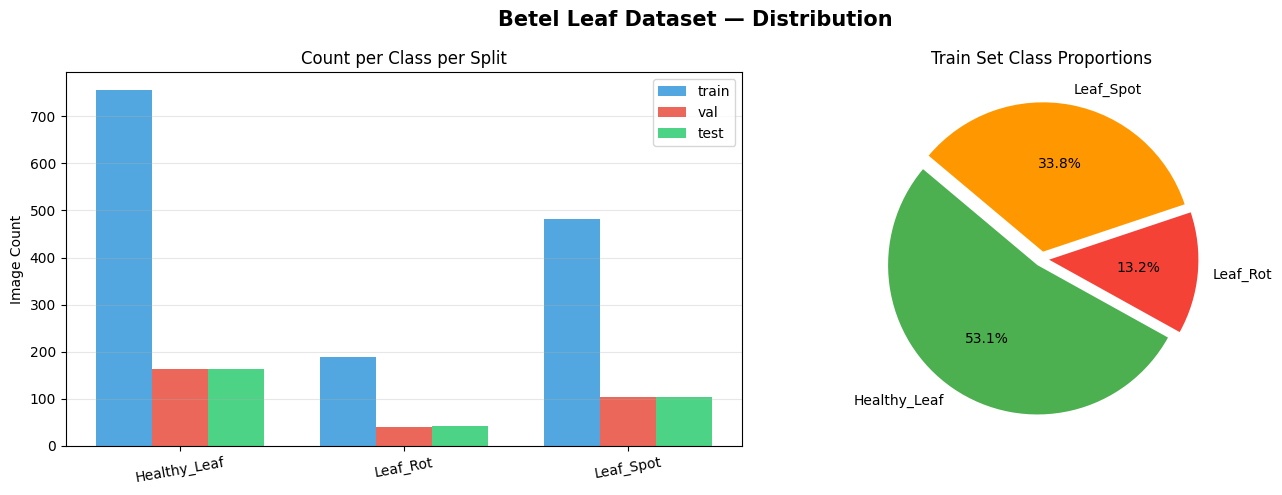

✅ Step 3 complete — Distribution chart saved.


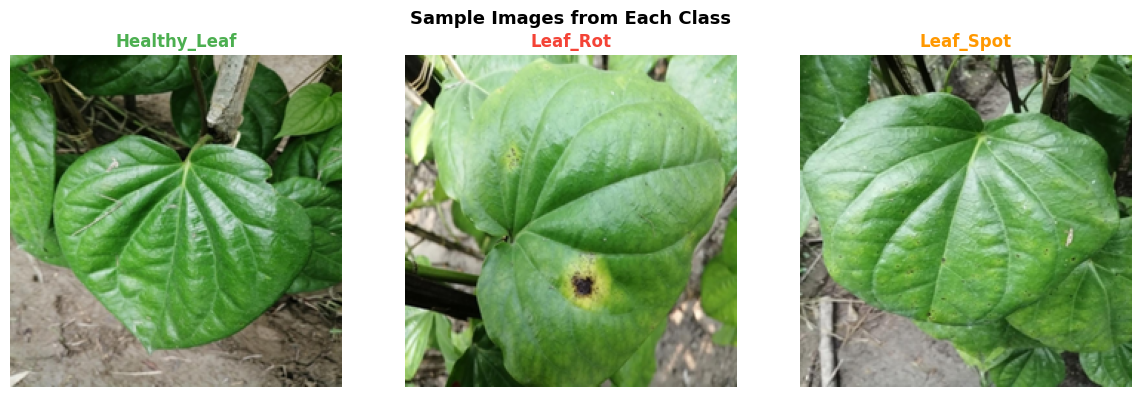

✅ Sample images displayed.


In [3]:
# ── Count images per class per split ──────────────────────────────────────
records = []
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        folder = DATASET_ROOT / split / cls
        if folder.exists():
            imgs = list(folder.glob("*.jpg")) + list(folder.glob("*.png")) + \
                   list(folder.glob("*.jpeg"))
            records.append({"Split": split, "Class": cls, "Count": len(imgs)})

df_dist = pd.DataFrame(records)
print("📊 Class Distribution Table")
print(df_dist.pivot(index="Class", columns="Split", values="Count").fillna(0).astype(int))

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Betel Leaf Dataset — Distribution", fontsize=15, fontweight="bold")

colors = ["#4CAF50", "#F44336", "#FF9800"]

# Bar chart
ax = axes[0]
splits = ["train", "val", "test"]
x = np.arange(len(CLASS_NAMES))
w = 0.25
for i, split in enumerate(splits):
    vals = [df_dist[(df_dist.Split==split) & (df_dist.Class==c)]["Count"].sum()
            for c in CLASS_NAMES]
    ax.bar(x + i*w, vals, w, label=split, color=["#3498db","#e74c3c","#2ecc71"][i], alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(CLASS_NAMES, rotation=10)
ax.set_title("Count per Class per Split")
ax.set_ylabel("Image Count")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Pie chart (train only)
ax2 = axes[1]
train_counts = [df_dist[(df_dist.Split=="train") & (df_dist.Class==c)]["Count"].sum()
                for c in CLASS_NAMES]
ax2.pie(train_counts, labels=CLASS_NAMES, colors=colors, autopct="%1.1f%%",
        startangle=140, explode=[0.05]*3)
ax2.set_title("Train Set Class Proportions")

plt.tight_layout()
plt.savefig("/kaggle/working/step3_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Step 3 complete — Distribution chart saved.")

# ── Show sample images ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
fig2.suptitle("Sample Images from Each Class", fontsize=13, fontweight="bold")
for ax, cls, color in zip(axes2, CLASS_NAMES, colors):
    folder = DATASET_ROOT / "train" / cls
    sample = list(folder.glob("*.*"))[0]
    img = Image.open(sample).resize((224, 224))
    ax.imshow(img)
    ax.set_title(cls, color=color, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/step3_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Sample images displayed.")

---
## ✅ Step 4 — Data Augmentation & Early Fusion Transform

**Early Fusion Strategy:**  
- Input Image 1: Original RGB (3 channels)  
- Input Image 2: Grayscale + Sobel Edge Map (1 channel) — extra structural info  
- **Concatenate → 4-channel tensor** → fed into modified ResNet50  

This is true *Early Fusion* as defined in the PDF: combining data at the very beginning.

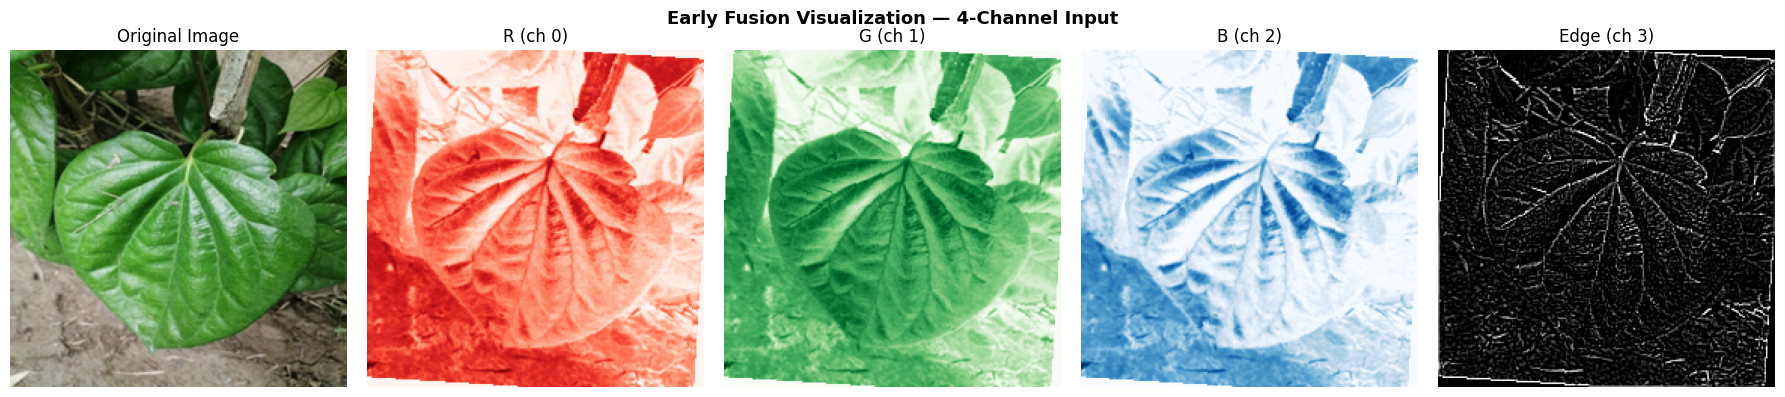

✅ Step 4 complete — Fused tensor shape: torch.Size([4, 224, 224])
   Channel breakdown: RGB (0-2) + Edge map (3) = 4 channels


In [4]:
import torchvision.transforms.functional as TF
from PIL import ImageFilter

# ── ImageNet mean/std (for 3 RGB channels) ─────────────────────────────────
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]
MEAN_EDGE = [0.5]
STD_EDGE  = [0.5]

class EarlyFusionTransform:
    """
    Early Fusion Transform:
      1. Resize to IMG_SIZE×IMG_SIZE
      2. Apply augmentation (training only)
      3. Build 4-channel tensor:
         - channels 0-2 : normalized RGB
         - channel 3    : Sobel edge map (grayscale structural info)
    """
    def __init__(self, is_train=True):
        self.is_train = is_train
        self.resize   = transforms.Resize((IMG_SIZE, IMG_SIZE))
        self.to_tensor = transforms.ToTensor()

        # Augmentation (train only) — from PDF: rotate ±15°, flip, brightness
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.05),
        ])

        self.normalize_rgb  = transforms.Normalize(MEAN_RGB, STD_RGB)
        self.normalize_edge = transforms.Normalize(MEAN_EDGE, STD_EDGE)

    def _get_edge_channel(self, pil_img):
        """Convert to grayscale + Sobel edge detection → single channel tensor."""
        gray = pil_img.convert("L")               # grayscale
        edge = gray.filter(ImageFilter.FIND_EDGES) # Sobel-like edge
        edge_t = self.to_tensor(edge)              # [1, H, W] in [0,1]
        return self.normalize_edge(edge_t)         # normalized

    def __call__(self, pil_img):
        img = self.resize(pil_img)
        if self.is_train:
            img = self.aug(img)

        # Channel 0-2: RGB
        rgb_t  = self.normalize_rgb(self.to_tensor(img))   # [3, H, W]

        # Channel 3: edge map
        edge_t = self._get_edge_channel(img)               # [1, H, W]

        # Early Fusion: concatenate along channel dim → [4, H, W]
        fused  = torch.cat([rgb_t, edge_t], dim=0)
        return fused


train_transform = EarlyFusionTransform(is_train=True)
val_transform   = EarlyFusionTransform(is_train=False)

# ── Visualize the fusion ───────────────────────────────────────────────────
sample_path = list((DATASET_ROOT / "train" / CLASS_NAMES[0]).glob("*.*"))[0]
sample_pil  = Image.open(sample_path).convert("RGB")
fused_tensor = train_transform(sample_pil)  # [4, 224, 224]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Early Fusion Visualization — 4-Channel Input", fontsize=13, fontweight="bold")

# Original
axes[0].imshow(sample_pil.resize((224, 224)))
axes[0].set_title("Original Image")
axes[0].axis("off")

# RGB channels
chan_names = ["R (ch 0)", "G (ch 1)", "B (ch 2)", "Edge (ch 3)"]
cmaps      = ["Reds", "Greens", "Blues", "gray"]
for i in range(4):
    axes[i+1].imshow(fused_tensor[i].numpy(), cmap=cmaps[i])
    axes[i+1].set_title(chan_names[i])
    axes[i+1].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/step4_early_fusion_channels.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Step 4 complete — Fused tensor shape: {fused_tensor.shape}")
print(f"   Channel breakdown: RGB (0-2) + Edge map (3) = 4 channels")

---
## ✅ Step 5 — Dataset & DataLoader Creation

In [5]:
class BetelLeafFusionDataset(Dataset):
    """Custom Dataset — loads images and applies Early Fusion transform."""

    def __init__(self, root_dir, class_names, transform=None):
        self.class_names = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform    = transform
        self.samples      = []   # (path, label)

        for cls in class_names:
            folder = Path(root_dir) / cls
            if not folder.exists():
                continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
                for img_path in sorted(folder.glob(ext)):
                    self.samples.append((str(img_path), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            # fallback: blank image
            img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Create datasets ────────────────────────────────────────────────────────
train_ds = BetelLeafFusionDataset(DATASET_ROOT / "train", CLASS_NAMES, train_transform)
val_ds   = BetelLeafFusionDataset(DATASET_ROOT / "val",   CLASS_NAMES, val_transform)
test_ds  = BetelLeafFusionDataset(DATASET_ROOT / "test",  CLASS_NAMES, val_transform)

print(f"📦 Dataset sizes  →  Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

# ── Weighted sampler to handle class imbalance (PDF Phase 1) ──────────────
labels_train = [s[1] for s in train_ds.samples]
class_counts = Counter(labels_train)
weights      = [1.0 / class_counts[l] for l in labels_train]
sampler      = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# ── DataLoaders ────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ── Verify one batch shape ──────────────────────────────────────────────────
batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n🔍 One batch check:")
print(f"   Image tensor shape : {batch_imgs.shape}  (B × 4 × H × W)")
print(f"   Label tensor shape : {batch_labels.shape}")
print(f"   Label values sample: {batch_labels[:8].tolist()}")
print(f"   Dtype              : {batch_imgs.dtype}")
print(f"   Value range [min,max]: [{batch_imgs.min():.3f}, {batch_imgs.max():.3f}]")
print("\n✅ Step 5 complete — DataLoaders ready!")

📦 Dataset sizes  →  Train: 1425  |  Val: 305  |  Test: 307

🔍 One batch check:
   Image tensor shape : torch.Size([32, 4, 224, 224])  (B × 4 × H × W)
   Label tensor shape : torch.Size([32])
   Label values sample: [2, 2, 0, 0, 0, 1, 2, 2]
   Dtype              : torch.float32
   Value range [min,max]: [-2.118, 2.640]

✅ Step 5 complete — DataLoaders ready!


---
## ✅ Step 6 — Early Fusion Model Building

**Architecture:**  
- Backbone: `ResNet50` (pretrained ImageNet)  
- **Modified first conv layer**: `in_channels = 4` (instead of default 3) to accept the 4-channel early fusion input  
- Final FC layer: 3 output classes  
- This follows PDF **Step 3.3**: *"For early fusion → change first conv layer if needed"*

In [6]:
class EarlyFusionResNet50(nn.Module):
    """
    Early Fusion ResNet50:
    - Load pretrained ResNet50
    - Replace conv1: 3-channel → 4-channel (RGB + Edge)
      * Pretrained RGB weights kept; edge channel initialized as grayscale avg of RGB weights
    - Replace fc: 2048 → num_classes
    - Dropout added before fc for regularization
    """

    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()

        # Load pretrained ResNet50
        self.backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)

        # ── Step 3.3: Modify first conv layer for 4-channel input ──────────
        old_conv  = self.backbone.conv1              # Conv2d(3, 64, 7, stride=2, padding=3)
        new_conv  = nn.Conv2d(
            in_channels=4,                          # 4 channels (RGB + Edge)
            out_channels=old_conv.out_channels,      # 64
            kernel_size=old_conv.kernel_size,        # 7
            stride=old_conv.stride,                  # 2
            padding=old_conv.padding,                # 3
            bias=False
        )

        # Initialize 4th channel weights = mean of 3 pretrained RGB channels
        # (preserve pretrained spatial features for the new edge channel)
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight          # copy RGB
            new_conv.weight[:, 3:4, :, :] = old_conv.weight.mean(dim=1, keepdim=True)

        self.backbone.conv1 = new_conv

        # ── Step 3.2: Replace final FC layer ──────────────────────────────
        in_features = self.backbone.fc.in_features   # 2048
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)   # x: [B, 4, 224, 224]


# ── Instantiate ────────────────────────────────────────────────────────────
model = EarlyFusionResNet50(num_classes=NUM_CLASSES, dropout=0.4)
model = model.to(DEVICE)

# ── Print model summary ───────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🏗️  Model: Early Fusion ResNet50")
print(f"   Input channels  : 4 (RGB + Edge map)")
print(f"   Output classes  : {NUM_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"   First conv      : {model.backbone.conv1}")
print(f"   Last FC         : {model.backbone.fc}")

# ── Forward pass check ─────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy   = torch.randn(2, 4, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out     = model(dummy)
print(f"\n✅ Forward pass OK — Output shape: {out.shape}  (batch=2, classes={NUM_CLASSES})")

# ── Loss, Optimizer, Scheduler (PDF Phase 3) ──────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # label smoothing helps generalization
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"\n⚙️  Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print(f"   Optimizer : AdamW  (lr={LR}, weight_decay=1e-4)")
print(f"   Scheduler : CosineAnnealing  (T_max={NUM_EPOCHS})")
print("\n✅ Step 6 complete — Model ready!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


🏗️  Model: Early Fusion ResNet50
   Input channels  : 4 (RGB + Edge map)
   Output classes  : 3 (Healthy_Leaf, Leaf_Rot, Leaf_Spot)
   Total params    : 23,517,315
   Trainable params: 23,517,315
   First conv      : Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   Last FC         : Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=2048, out_features=3, bias=True)
)

✅ Forward pass OK — Output shape: torch.Size([2, 3])  (batch=2, classes=3)

⚙️  Loss      : CrossEntropyLoss (label_smoothing=0.1)
   Optimizer : AdamW  (lr=0.0001, weight_decay=1e-4)
   Scheduler : CosineAnnealing  (T_max=20)

✅ Step 6 complete — Model ready!


---
## ✅ Step 7 — Training Loop with Validation

Follows PDF **Phase 4**:  
- Train full pass → compute train loss  
- Evaluate on val → val loss + accuracy  
- Save best model checkpoint (lowest val loss)

In [7]:
CKPT_PATH = "/kaggle/working/best_early_fusion_model.pth"

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs      = model(imgs)
        loss         = criterion(outputs, labels)
        total_loss  += loss.item() * imgs.size(0)
        preds        = outputs.argmax(dim=1)
        correct     += (preds == labels).sum().item()
        total       += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels))


# ── Training loop (PDF Phase 4) ────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [],
           "train_acc": [],  "val_acc": [],
           "val_f1": [],     "lr": []}

best_val_loss = float("inf")
best_val_acc  = 0.0
patience      = 7
no_improve    = 0

print(f"🚀 Training for {NUM_EPOCHS} epochs on {DEVICE}")
print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} "
      f"{'Val Acc':>9} {'Val F1':>8} {'LR':>10}")
print("-" * 72)

start_total = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, criterion, DEVICE)
    val_f1  = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    cur_lr  = optimizer.param_groups[0]["lr"]
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(cur_lr)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc  = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        }, CKPT_PATH)
        no_improve = 0
        marker = " ✓ SAVED"
    else:
        no_improve += 1

    elapsed = time.time() - t0
    print(f"{epoch:>6} {train_loss:>11.4f} {train_acc*100:>9.2f}% "
          f"{val_loss:>10.4f} {val_acc*100:>8.2f}% "
          f"{val_f1:>8.4f} {cur_lr:>10.2e}  "
          f"({elapsed:.1f}s){marker}")

    # Early stopping
    if no_improve >= patience:
        print(f"\n⏹️  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
        break

total_time = time.time() - start_total
print(f"\n✅ Training complete in {total_time/60:.1f} min")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Best val acc  : {best_val_acc*100:.2f}%")
print(f"   Checkpoint    : {CKPT_PATH}")

🚀 Training for 20 epochs on cuda
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
------------------------------------------------------------------------
     1      0.5934     84.21%     0.4782    90.16%   0.9010   1.00e-04  (22.8s) ✓ SAVED
     2      0.4728     91.30%     0.5008    90.49%   0.9068   9.94e-05  (22.1s)
     3      0.4190     94.81%     0.4668    93.11%   0.9309   9.76e-05  (22.2s) ✓ SAVED
     4      0.4126     93.82%     0.4507    93.11%   0.9310   9.46e-05  (22.6s) ✓ SAVED
     5      0.3971     95.16%     0.4593    91.48%   0.9148   9.05e-05  (21.9s)
     6      0.3865     95.58%     0.4928    89.84%   0.8990   8.55e-05  (21.7s)
     7      0.3642     96.98%     0.4469    91.80%   0.9181   7.96e-05  (23.1s) ✓ SAVED
     8      0.3531     97.68%     0.4546    93.11%   0.9310   7.30e-05  (21.7s)
     9      0.3545     97.68%     0.4466    91.80%   0.9180   6.58e-05  (22.4s) ✓ SAVED
    10      0.3360     98.46%     0.4543    93.44%   0.9341   5

---
## ✅ Step 8 — Training Curves Visualization

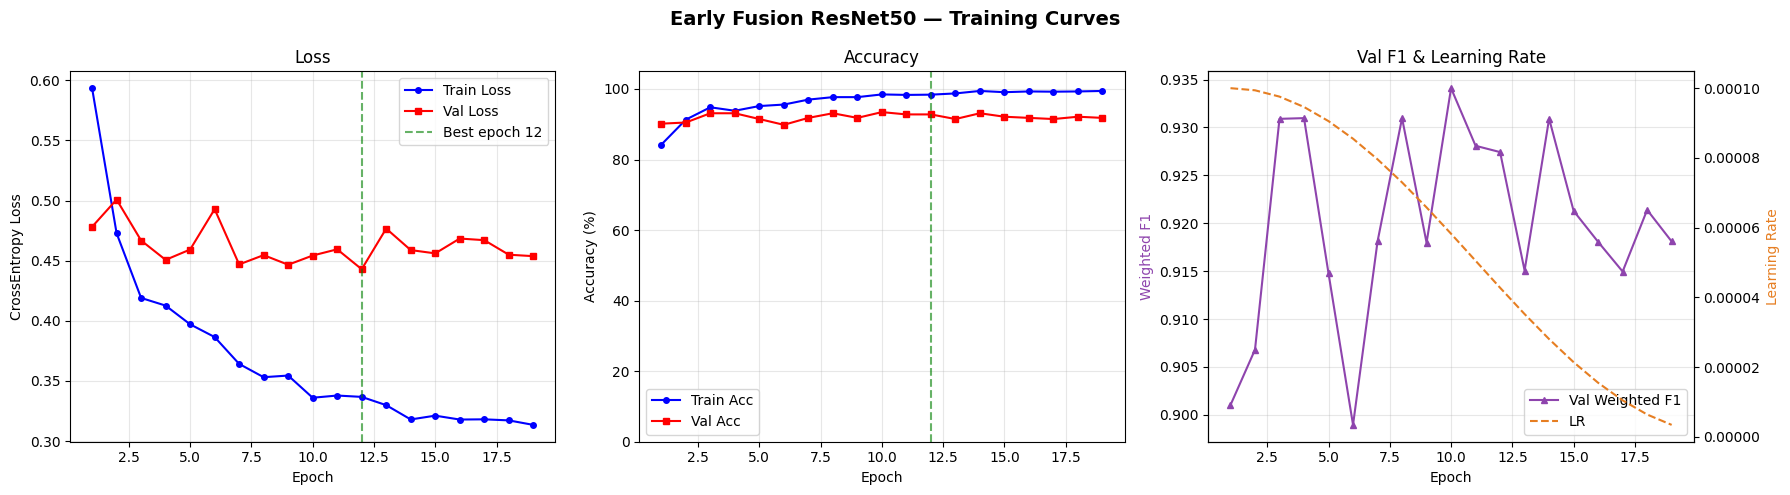


📈 Training Summary:
   Best epoch     : 12
   Best val loss  : 0.4429
   Best val acc   : 93.44%
   Best val F1    : 0.9341
✅ Step 8 complete — Training curves saved.


In [8]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Early Fusion ResNet50 — Training Curves", fontsize=14, fontweight="bold")

# Loss
ax = axes[0]
ax.plot(epochs_ran, history["train_loss"], "b-o", ms=4, label="Train Loss")
ax.plot(epochs_ran, history["val_loss"],   "r-s", ms=4, label="Val Loss")
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("CrossEntropy Loss")
ax.legend()
ax.grid(alpha=0.3)
best_ep = history["val_loss"].index(min(history["val_loss"])) + 1
ax.axvline(best_ep, color="green", linestyle="--", alpha=0.6, label=f"Best epoch {best_ep}")
ax.legend()

# Accuracy
ax2 = axes[1]
ax2.plot(epochs_ran, [v*100 for v in history["train_acc"]], "b-o", ms=4, label="Train Acc")
ax2.plot(epochs_ran, [v*100 for v in history["val_acc"]],   "r-s", ms=4, label="Val Acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim([0, 105])
ax2.legend()
ax2.grid(alpha=0.3)
ax2.axvline(best_ep, color="green", linestyle="--", alpha=0.6)

# F1 + LR
ax3 = axes[2]
color_f1 = "#8e44ad"
color_lr = "#e67e22"
ln1 = ax3.plot(epochs_ran, history["val_f1"], color=color_f1, marker="^", ms=4, label="Val Weighted F1")
ax3b = ax3.twinx()
ln2 = ax3b.plot(epochs_ran, history["lr"], color=color_lr, linestyle="--", label="LR")
ax3.set_title("Val F1 & Learning Rate")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Weighted F1", color=color_f1)
ax3b.set_ylabel("Learning Rate", color=color_lr)
lines = ln1 + ln2
ax3.legend(lines, [l.get_label() for l in lines])
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/step8_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Print summary table
print(f"\n📈 Training Summary:")
print(f"   Best epoch     : {best_ep}")
print(f"   Best val loss  : {min(history['val_loss']):.4f}")
print(f"   Best val acc   : {max(history['val_acc'])*100:.2f}%")
print(f"   Best val F1    : {max(history['val_f1']):.4f}")
print("✅ Step 8 complete — Training curves saved.")

---
## ✅ Step 9 — Final Test Evaluation & Metrics

Follows PDF **Phase 6**: Run best model on test set **once**, report Accuracy, Weighted F1, Macro F1, Per-class F1.

In [9]:
# ── Load best checkpoint ──────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"✅ Loaded best checkpoint from epoch {ckpt['epoch']}")
print(f"   Checkpoint val loss : {ckpt['val_loss']:.4f}")
print(f"   Checkpoint val acc  : {ckpt['val_acc']*100:.2f}%")
print(f"   Checkpoint val F1   : {ckpt['val_f1']:.4f}")

# ── Run on TEST set (only once, as required by PDF) ───────────────────────
print("\n🔬 Running inference on test set...")
test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, criterion, DEVICE)

acc_pct       = test_acc * 100
weighted_f1   = f1_score(test_true, test_preds, average="weighted", zero_division=0)
macro_f1      = f1_score(test_true, test_preds, average="macro",    zero_division=0)
per_class_f1  = f1_score(test_true, test_preds, average=None,       zero_division=0)

# ── Print results table (PDF Phase 6 format) ──────────────────────────────
print("\n" + "=" * 50)
print("  FINAL TEST RESULTS — Early Fusion ResNet50")
print("=" * 50)
print(f"  Metric               Value")
print(f"  {'Accuracy':<22}{acc_pct:.2f}%")
print(f"  {'Weighted F1':<22}{weighted_f1:.4f}")
print(f"  {'Macro F1':<22}{macro_f1:.4f}")
print(f"  {'Test Loss':<22}{test_loss:.4f}")
print("" + "-" * 50)
print("  Per-Class F1:")
for cls, f1 in zip(CLASS_NAMES, per_class_f1):
    bar = "█" * int(f1 * 30)
    print(f"    {cls:<18} {f1:.4f}  {bar}")
print("=" * 50)

# ── Full classification report ────────────────────────────────────────────
print("\n📋 Detailed Classification Report:")
report = classification_report(test_true, test_preds,
                                target_names=CLASS_NAMES,
                                digits=4)
print(report)

# ── Save results to CSV ───────────────────────────────────────────────────
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1", "Macro F1"] +
               [f"F1_{c}" for c in CLASS_NAMES],
    "Value":  [acc_pct/100, weighted_f1, macro_f1] + list(per_class_f1)
})
results_df.to_csv("/kaggle/working/step9_test_results.csv", index=False)
print("\n✅ Step 9 complete — Results saved to step9_test_results.csv")

✅ Loaded best checkpoint from epoch 12
   Checkpoint val loss : 0.4429
   Checkpoint val acc  : 92.79%
   Checkpoint val F1   : 0.9274

🔬 Running inference on test set...

  FINAL TEST RESULTS — Early Fusion ResNet50
  Metric               Value
  Accuracy              95.11%
  Weighted F1           0.9510
  Macro F1              0.9488
  Test Loss             0.3863
--------------------------------------------------
  Per-Class F1:
    Healthy_Leaf       0.9632  ████████████████████████████
    Leaf_Rot           0.9512  ████████████████████████████
    Leaf_Spot          0.9320  ███████████████████████████

📋 Detailed Classification Report:
              precision    recall  f1-score   support

Healthy_Leaf     0.9573    0.9691    0.9632       162
    Leaf_Rot     0.9512    0.9512    0.9512        41
   Leaf_Spot     0.9412    0.9231    0.9320       104

    accuracy                         0.9511       307
   macro avg     0.9499    0.9478    0.9488       307
weighted avg     0.9510

---
## ✅ Step 10 — Confusion Matrix & Per-Class Analysis

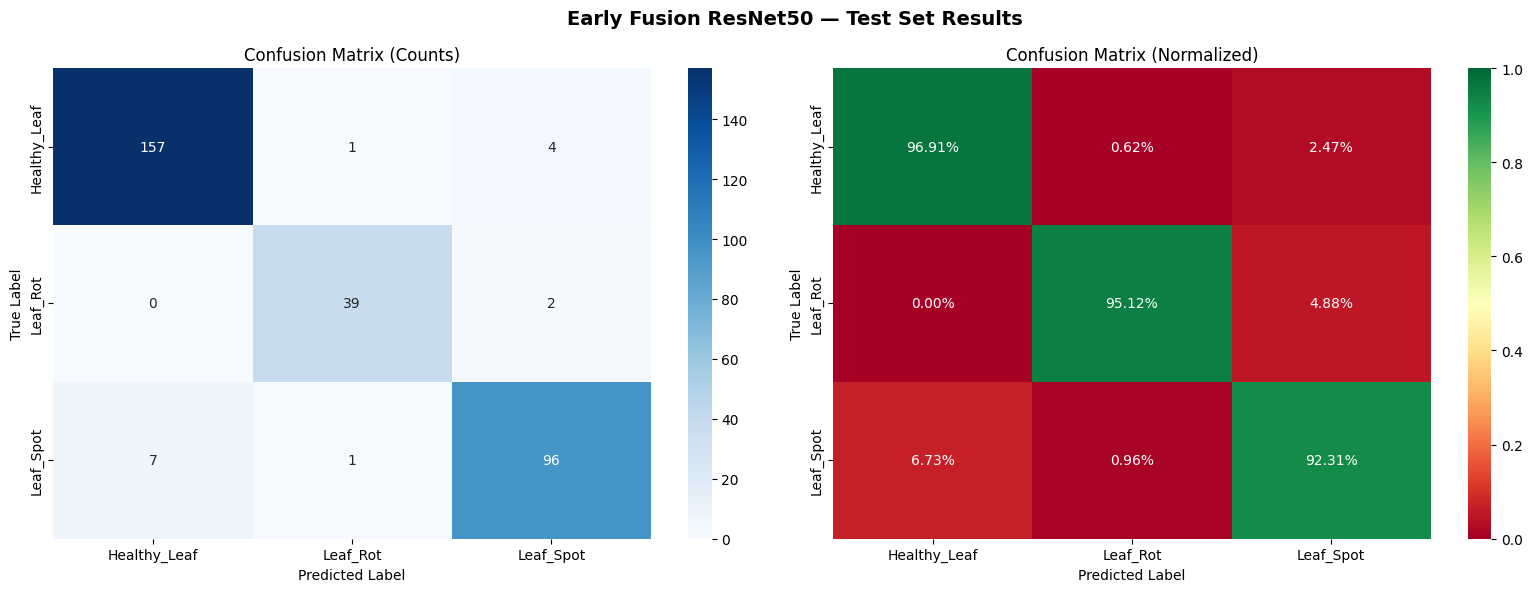

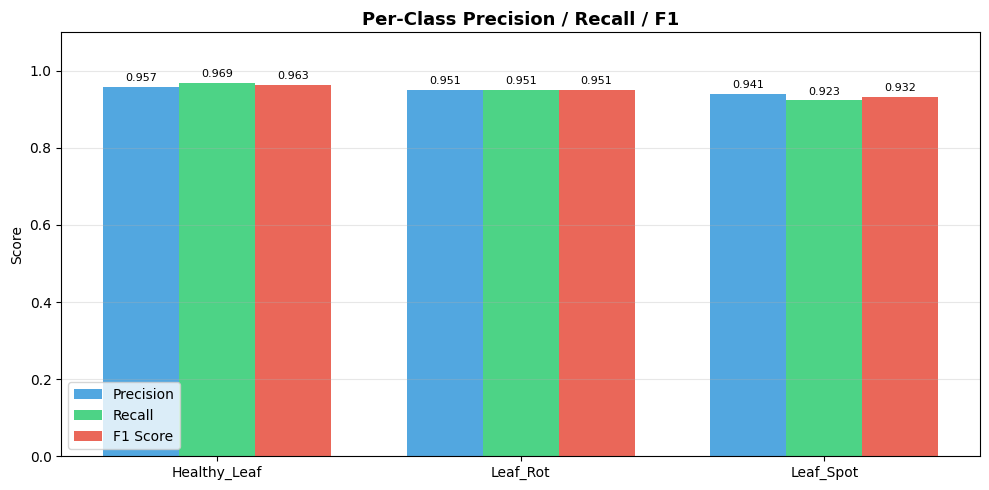


════════════════════════════════════════════════════════════
  🌿 EARLY FUSION RESNET50 — FINAL SUMMARY
════════════════════════════════════════════════════════════
  Fusion Type     : Early Fusion (RGB + Edge channel)
  Input Shape     : [B, 4, 224, 224]
  Backbone        : ResNet50 (pretrained ImageNet)
  Classes         : Healthy_Leaf, Leaf_Rot, Leaf_Spot
  Test Accuracy   : 95.11%
  Weighted F1     : 0.9510
  Macro F1        : 0.9488
────────────────────────────────────────────────────────────
  Per-class F1:
    Healthy_Leaf        F1=0.9632  Prec=0.9573  Rec=0.9691
    Leaf_Rot            F1=0.9512  Prec=0.9512  Rec=0.9512
    Leaf_Spot           F1=0.9320  Prec=0.9412  Rec=0.9231
────────────────────────────────────────────────────────────
  Saved files:
    ✓ /kaggle/working/step3_distribution.png
    ✓ /kaggle/working/step3_samples.png
    ✓ /kaggle/working/step4_early_fusion_channels.png
    ✓ /kaggle/working/step8_training_curves.png
    ✓ /kaggle/working/step9_test_results.

In [10]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)  # row-normalized

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Early Fusion ResNet50 — Test Set Results", fontsize=14, fontweight="bold")

# Raw count confusion matrix
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title("Confusion Matrix (Counts)", fontsize=12)
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")

# Normalized confusion matrix
ax2 = axes[1]
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="RdYlGn",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2,
            vmin=0, vmax=1)
ax2.set_title("Confusion Matrix (Normalized)", fontsize=12)
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("/kaggle/working/step10_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Per-class bar chart ───────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CLASS_NAMES))
width = 0.25

# Precision, Recall, F1 per class
from sklearn.metrics import precision_score, recall_score
per_prec   = precision_score(test_true, test_preds, average=None, zero_division=0)
per_recall = recall_score(test_true,    test_preds, average=None, zero_division=0)

bars1 = ax.bar(x - width, per_prec,      width, label="Precision", color="#3498db", alpha=0.85)
bars2 = ax.bar(x,          per_recall,   width, label="Recall",    color="#2ecc71", alpha=0.85)
bars3 = ax.bar(x + width,  per_class_f1, width, label="F1 Score",  color="#e74c3c", alpha=0.85)

ax.set_title("Per-Class Precision / Recall / F1", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim([0, 1.1])
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Add value annotations
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/step10_per_class_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Final Summary Card ────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  🌿 EARLY FUSION RESNET50 — FINAL SUMMARY")
print("═" * 60)
print(f"  Fusion Type     : Early Fusion (RGB + Edge channel)")
print(f"  Input Shape     : [B, 4, 224, 224]")
print(f"  Backbone        : ResNet50 (pretrained ImageNet)")
print(f"  Classes         : {', '.join(CLASS_NAMES)}")
print(f"  Test Accuracy   : {acc_pct:.2f}%")
print(f"  Weighted F1     : {weighted_f1:.4f}")
print(f"  Macro F1        : {macro_f1:.4f}")
print("─" * 60)
print("  Per-class F1:")
for cls, f1, prec, rec in zip(CLASS_NAMES, per_class_f1, per_prec, per_recall):
    print(f"    {cls:<18}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}")
print("─" * 60)
print("  Saved files:")
for f in ["/kaggle/working/step3_distribution.png",
           "/kaggle/working/step3_samples.png",
           "/kaggle/working/step4_early_fusion_channels.png",
           "/kaggle/working/step8_training_curves.png",
           "/kaggle/working/step9_test_results.csv",
           "/kaggle/working/step10_confusion_matrix.png",
           "/kaggle/working/step10_per_class_metrics.png",
           "/kaggle/working/best_early_fusion_model.pth"]:
    print(f"    ✓ {f}")
print("═" * 60)
print("  ✅ Step 10 complete — Pipeline finished successfully!")
print("═" * 60)